# Hawk Eye: Drone Detection -- YOLOv11x Fine-tune (Google Colab T4)
**Detects:** Real outdoor drones + 3D printed indoor drones

### BEFORE RUNNING:
1. Runtime → Change runtime type → **T4 GPU**
2. Run all cells top to bottom

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 1 - Install & verify GPU
# ════════════════════════════════════════════════════════════
!pip install ultralytics roboflow -q

import torch
from pathlib import Path

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
n_gpu = torch.cuda.device_count()
for i in range(n_gpu):
    props = torch.cuda.get_device_properties(i)
    print(f'  [{i}] {props.name}  {props.total_memory // 1024**3} GB')

assert torch.cuda.is_available(), 'ERROR: No GPU - Runtime → Change runtime type → T4 GPU'

DEVICE = '0'
BATCH  = 16
print(f'\n>>> Device={DEVICE}  Batch={BATCH}  - ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.1 MB/s eta 0:00:00
PyTorch : 2.11.0+cu128
CUDA    : True
  [0] Tesla T4  14 GB

>>> Device=0  Batch=16  - ready


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 2 - Download YOUR Roboflow dataset (auto latest version)
# ════════════════════════════════════════════════════════════
from roboflow import Roboflow
from pathlib import Path

import getpass
API_KEY = getpass.getpass('Enter your Roboflow API Key: ')

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace('ROBOFLOW_USERNAME_HERE').project('project-name-here')

versions = project.versions()
latest   = max(versions, key=lambda v: v.version)
print(f'Found {len(versions)} version(s) - downloading latest: v{latest.version}')

dataset = latest.download('yolov8', location='/content/custom')
print('\nDownloaded. Structure:')
!find /content/custom -type d | sort

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 3 - Download outdoor drone dataset
# ════════════════════════════════════════════════════════════
import subprocess

!pip install kaggle -q

# Download via kaggle API
r = subprocess.run(
    ['kaggle', 'datasets', 'download',
     '-d', 'muki2003/yolo-drone-detection-dataset',
     '-p', '/content/outdoor', '--unzip'],
    capture_output=True, text=True
)
print(r.stdout or '(no stdout)')
if r.returncode != 0:
    print('STDERR:', r.stderr)
    print('WARNING: outdoor dataset failed - training on custom data only (still fine)')
else:
    print('Outdoor dataset downloaded OK')
    !find /content/outdoor -type d | sort

Dataset URL: https://www.kaggle.com/datasets/muki2003/yolo-drone-detection-dataset
License(s): other


Outdoor dataset downloaded OK
/content/outdoor
/content/outdoor/drone_dataset
/content/outdoor/drone_dataset/train
/content/outdoor/drone_dataset/train/images
/content/outdoor/drone_dataset/train/labels
/content/outdoor/drone_dataset/valid
/content/outdoor/drone_dataset/valid/images
/content/outdoor/drone_dataset/valid/labels


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 4 - Merge all datasets
# ════════════════════════════════════════════════════════════
import shutil
from pathlib import Path

MERGED = Path('/content/merged')
for split in ['train', 'valid']:
    (MERGED / split / 'images').mkdir(parents=True, exist_ok=True)
    (MERGED / split / 'labels').mkdir(parents=True, exist_ok=True)

def copy_split(img_dir, lbl_dir, dst_split, tag):
    img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)
    if not img_dir.exists():
        print(f'  SKIP: {img_dir} does not exist')
        return 0
    copied = 0
    for img in img_dir.glob('*'):
        if img.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        dst_img = MERGED / dst_split / 'images' / f'{tag}_{img.name}'
        dst_lbl = MERGED / dst_split / 'labels' / f'{tag}_{img.stem}.txt'
        shutil.copy(img, dst_img)
        lbl = lbl_dir / (img.stem + '.txt')
        if lbl.exists():
            shutil.copy(lbl, dst_lbl)
        else:
            dst_lbl.write_text('')
        copied += 1
    return copied

CUSTOM = Path('/content/custom')
custom_train_imgs = CUSTOM / 'train' / 'images'
custom_valid_imgs = CUSTOM / 'valid' / 'images'
if not custom_train_imgs.exists():
    custom_train_imgs = CUSTOM / 'train'
    custom_valid_imgs = CUSTOM / 'valid'

n  = copy_split(custom_train_imgs, custom_train_imgs.parent / 'labels', 'train', 'c')
n += copy_split(custom_valid_imgs, custom_valid_imgs.parent / 'labels', 'valid', 'c')
print(f'Custom dataset  : {n} images')

OUTDOOR = Path('/content/outdoor')
outdoor_total = 0
if OUTDOOR.exists():
    img_dirs = [p for p in OUTDOOR.rglob('images') if p.is_dir()]
    if not img_dirs:
        img_dirs = [OUTDOOR]
    for img_dir in img_dirs:
        parent = img_dir.parent.name.lower()
        dst = 'valid' if ('val' in parent or 'test' in parent) else 'train'
        lbl_dir = img_dir.parent / 'labels'
        if not lbl_dir.exists():
            lbl_dir = img_dir.parent.parent / 'labels' / img_dir.parent.name
        if not lbl_dir.exists():
            lbl_dir = img_dir
        k = copy_split(img_dir, lbl_dir, dst, 'o')
        outdoor_total += k
        if k > 0:
            print(f'  Outdoor [{dst}]: {k} images')

print(f'Outdoor dataset : {outdoor_total} images')
tr = len(list((MERGED/'train'/'images').glob('*')))
va = len(list((MERGED/'valid'/'images').glob('*')))
print(f'\nMERGED TOTAL → train: {tr}  |  valid: {va}')

  SKIP: /content/custom/train does not exist
  SKIP: /content/custom/valid does not exist
Custom dataset  : 0 images
  Outdoor [valid]: 347 images
  Outdoor [train]: 1012 images
Outdoor dataset : 1359 images

MERGED TOTAL → train: 1012  |  valid: 347


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 5 - Convert polygon labels → bounding boxes + fix class IDs
# ════════════════════════════════════════════════════════════
from pathlib import Path

converted = 0
fixed_cls = 0
empty     = 0

for lbl in Path('/content/merged').rglob('*.txt'):
    lines = lbl.read_text().strip().splitlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = '0'
        if parts[0] != '0':
            fixed_cls += 1
        values = list(map(float, parts[1:]))
        if len(values) == 4:
            new_lines.append(f'{cls} {values[0]:.6f} {values[1]:.6f} {values[2]:.6f} {values[3]:.6f}')
        elif len(values) >= 6 and len(values) % 2 == 0:
            xs = values[0::2]
            ys = values[1::2]
            x_center = (min(xs) + max(xs)) / 2
            y_center = (min(ys) + max(ys)) / 2
            width    = max(xs) - min(xs)
            height   = max(ys) - min(ys)
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            width    = max(0.001, min(1.0, width))
            height   = max(0.001, min(1.0, height))
            new_lines.append(f'{cls} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}')
            converted += 1
    if not new_lines:
        empty += 1
    lbl.write_text('\n'.join(new_lines))

print(f'Polygon → bbox : {converted}')
print(f'Class fixes    : {fixed_cls}')
print(f'Empty labels   : {empty}')
print('All labels in YOLO detection format ✓')

yaml = """train: /content/merged/train/images
val: /content/merged/valid/images
nc: 1
names: ['drone']
"""
Path('/content/merged/data.yaml').write_text(yaml)
print('data.yaml written ✓')

Polygon → bbox : 0
Class fixes    : 0
Empty labels   : 0
All labels in YOLO detection format ✓
data.yaml written ✓


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 6 - Download pre-trained YOLOv11x drone weights
# ════════════════════════════════════════════════════════════
from pathlib import Path

!wget -q --show-progress \
    'https://huggingface.co/doguilmak/Drone-Detection-YOLOv11x/resolve/main/weight/best.pt?download=true' \
    -O /content/pretrained.pt

sz = Path('/content/pretrained.pt').stat().st_size / 1e6
assert sz > 50, f'Download failed - file too small: {sz:.1f} MB'
print(f'Pretrained weights: {sz:.1f} MB  ✓')

/content/pretrained 100%[===================>] 109.08M  51.7MB/s    in 2.1s    
Pretrained weights: 114.4 MB  ✓


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 7 - TRAIN
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

model = YOLO('/content/pretrained.pt')

model.train(
    data         = '/content/merged/data.yaml',
    imgsz        = 640,
    batch        = BATCH,
    epochs       = 80,
    patience     = 20,
    device       = DEVICE,
    workers      = 2,
    freeze       = 10,
    lr0          = 0.0005,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs= 3,
    close_mosaic = 15,
    degrees      = 45,
    translate    = 0.1,
    scale        = 0.5,
    fliplr       = 0.5,
    flipud       = 0.2,
    mosaic       = 1.0,
    mixup        = 0.15,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    erasing      = 0.3,
    project      = '/content/runs',
    name         = 'drone_final',
    exist_ok     = True,
    save         = True,
    save_period  = 10,
    plots        = True,
    verbose      = True,
)

print('\n' + '='*50)
print('TRAINING COMPLETE')
print('='*50)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged/data.yaml, degrees=45, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

In [7]:
# ════════════════════════════════════════════════════════════
# CELL 8 - Validate
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

best = YOLO('/content/runs/drone_final/weights/best.pt')
m = best.val(data='/content/merged/data.yaml', imgsz=640, verbose=False)

print('\n════ FINAL MODEL METRICS ════')
print(f'  mAP@50     : {m.box.map50:.4f}')
print(f'  mAP@50-95  : {m.box.map:.4f}')
print(f'  Precision  : {m.box.mp:.4f}')
print(f'  Recall     : {m.box.mr:.4f}')
print('════════════════════════════')

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1745.6±984.5 MB/s, size: 99.9 KB)
val: Scanning /content/merged/valid/labels.cache... 347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 347/347 112.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.0it/s 21.6s
                   all        347        369      0.945      0.859      0.928      0.549
Speed: 2.1ms preprocess, 53.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val

════ FINAL MODEL METRICS ════
  mAP@50     : 0.9280
  mAP@50-95  : 0.5487
  Precision  : 0.9449
  Recall     : 0.8591
════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 9 - Show training curves
# ════════════════════════════════════════════════════════════
from IPython.display import Image, display
from pathlib import Path

run = Path('/content/runs/drone_final')
for fname in ['results.png', 'confusion_matrix_normalized.png', 'val_batch0_pred.jpg']:
    p = run / fname
    if not p.exists():
        p = run / fname.replace('_normalized', '')
    if p.exists():
        print(f'\n── {fname} ──')
        display(Image(str(p), width=900))

Results saved to /content/test_preds/run
[OUTDOOR] o_foto05018.jpg


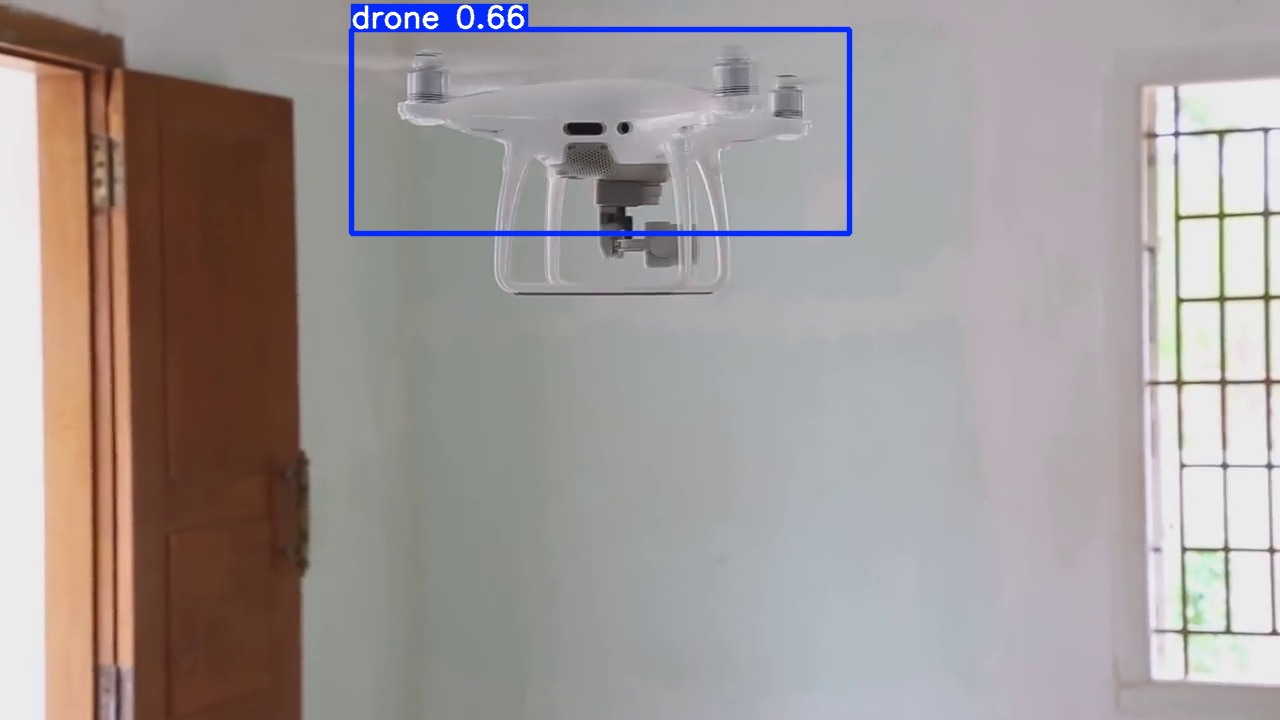

Results saved to /content/test_preds/run
[OUTDOOR] o_foto01596.jpg


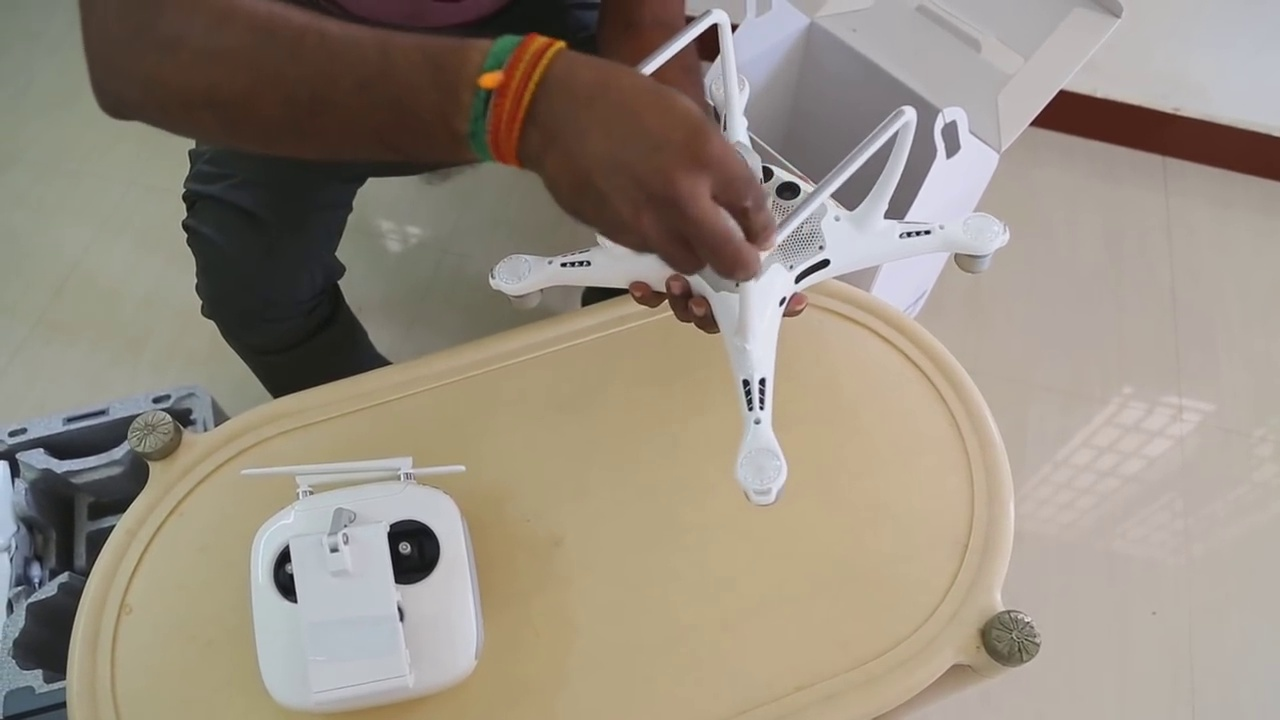

Results saved to /content/test_preds/run
[OUTDOOR] o_foto01770.jpg


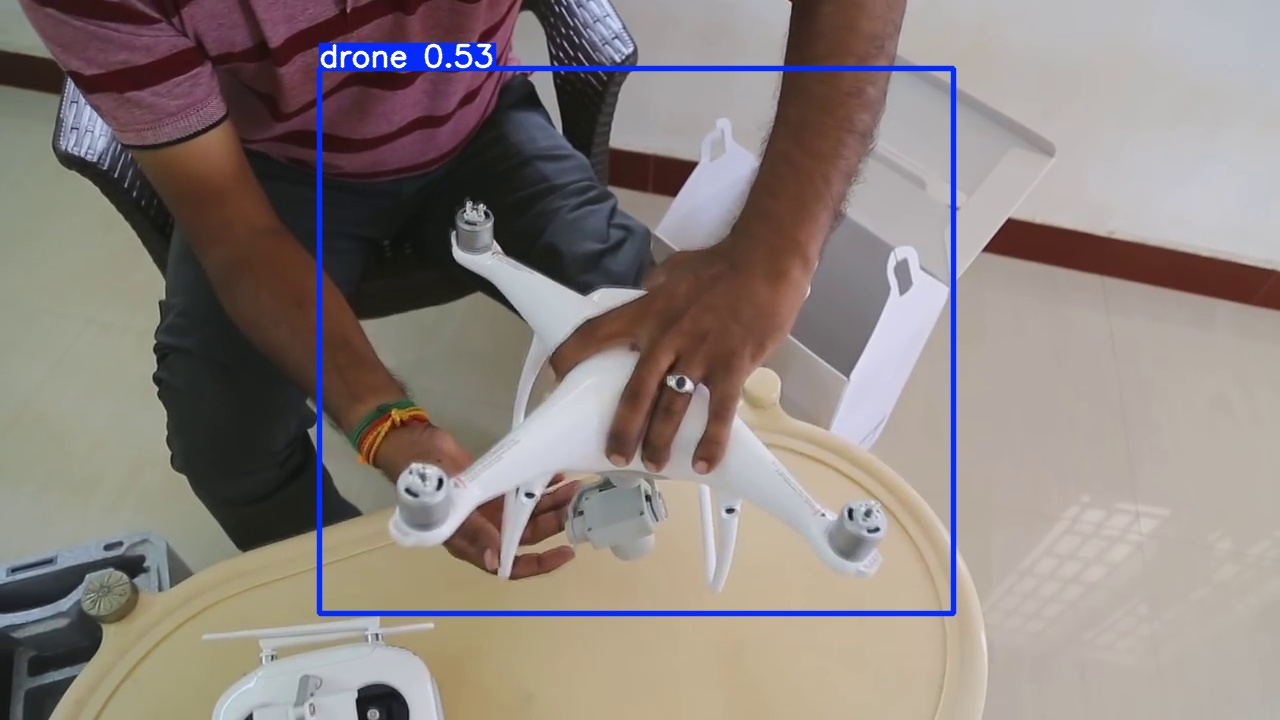

Results saved to /content/test_preds/run
[OUTDOOR] o_foto14907.jpg


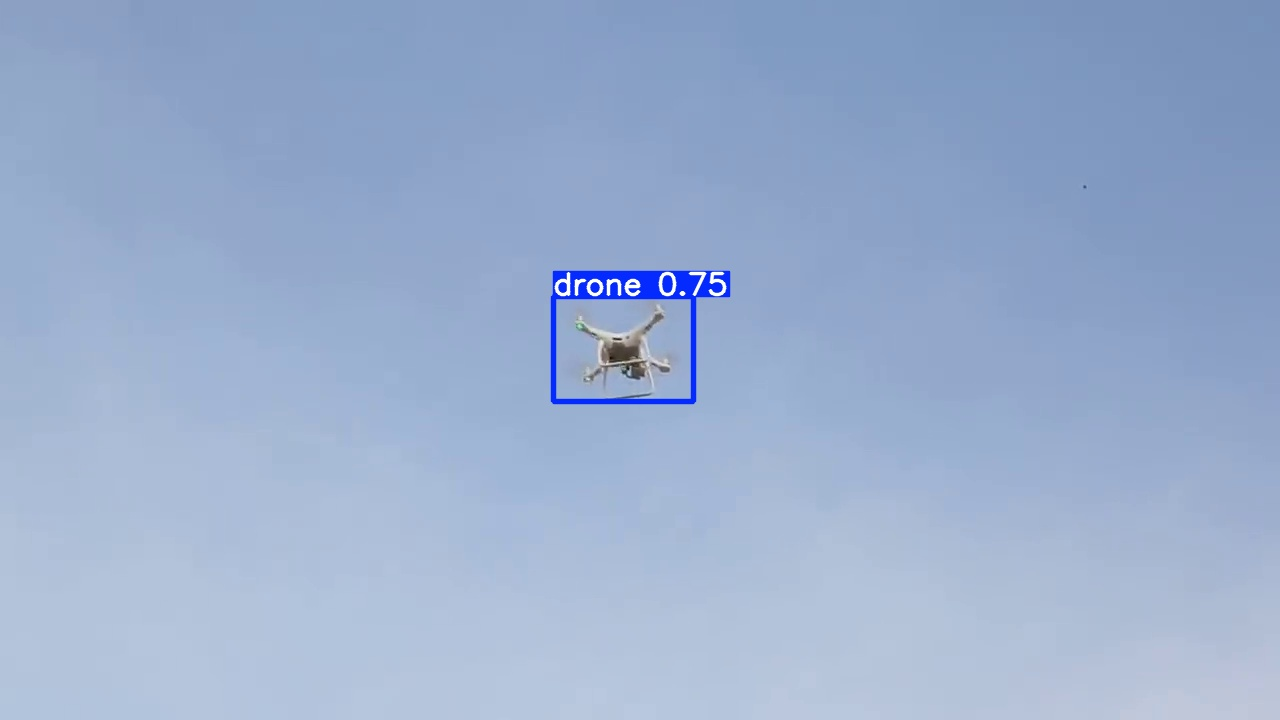

Results saved to /content/test_preds/run
[OUTDOOR] o_foto04989.jpg


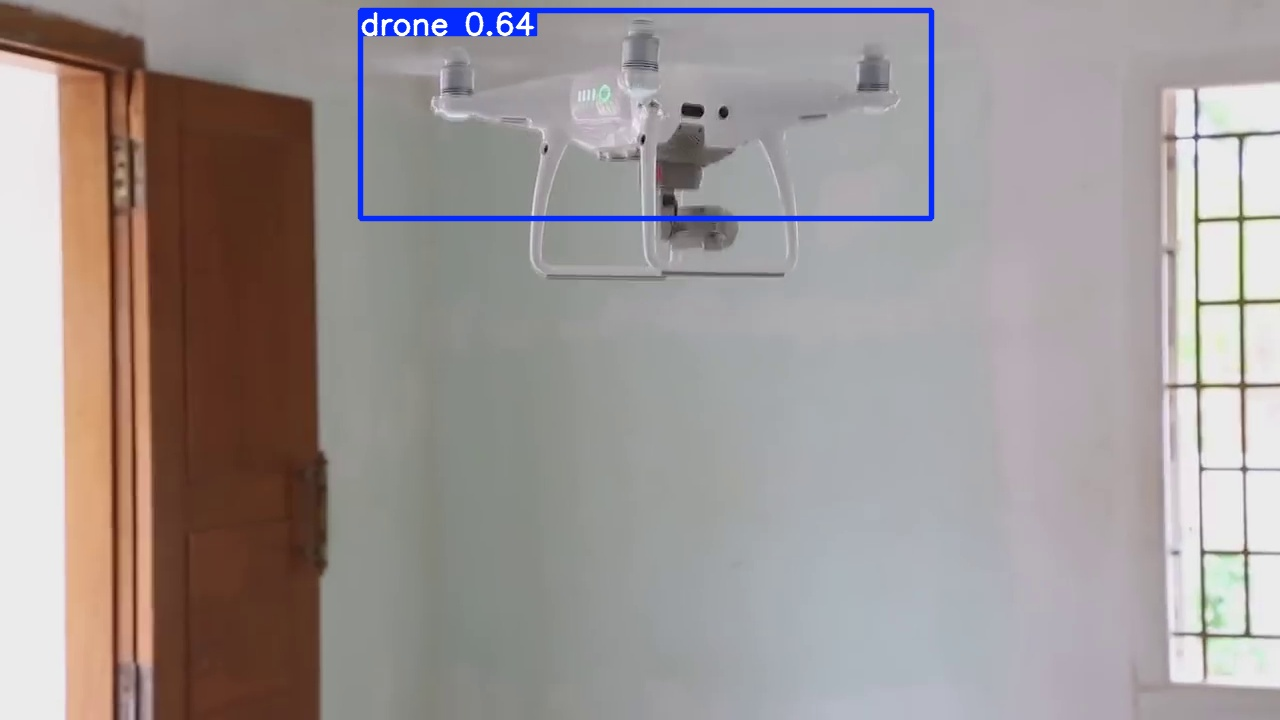

Results saved to /content/test_preds/run
[OUTDOOR] o_0318.jpg


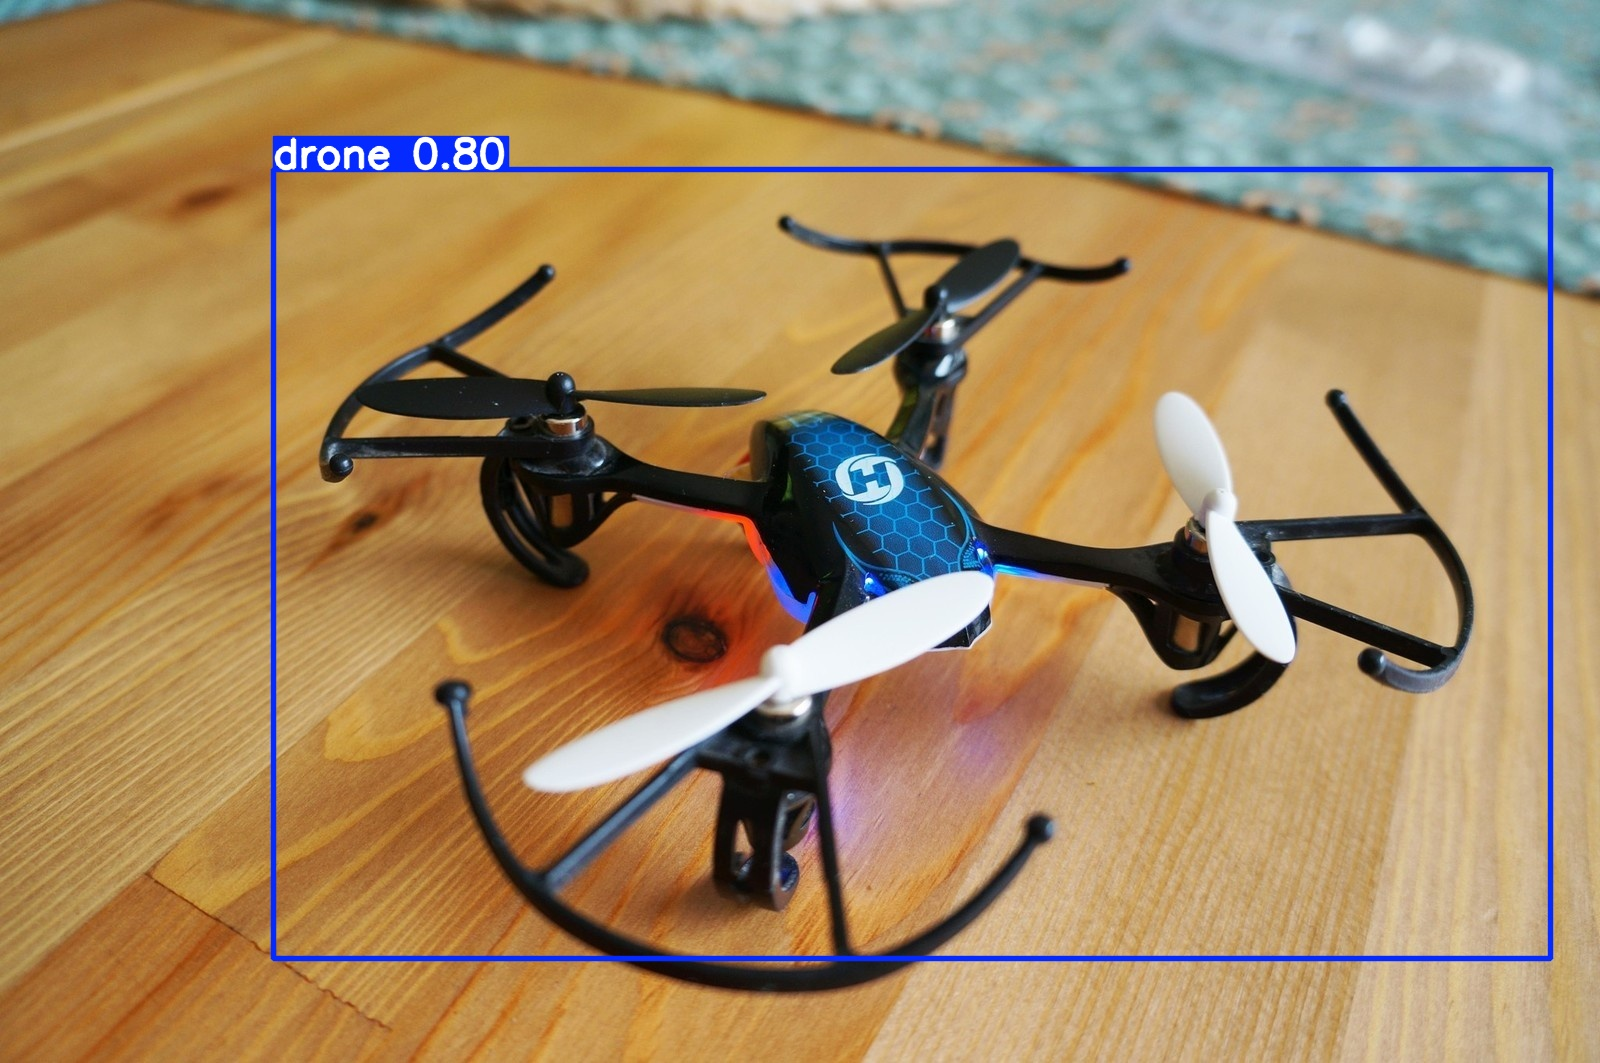

Results saved to /content/test_preds/run
[OUTDOOR] o_foto14646.jpg


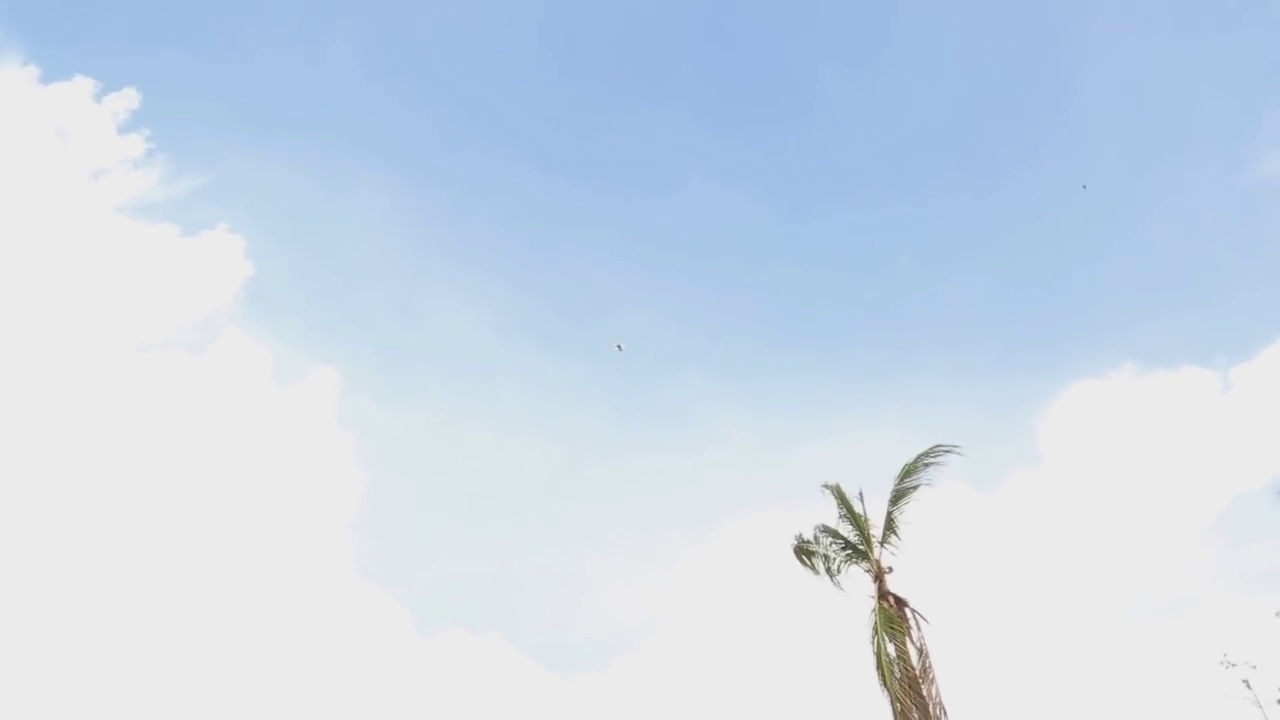

Results saved to /content/test_preds/run
[OUTDOOR] o_foto00349.jpg


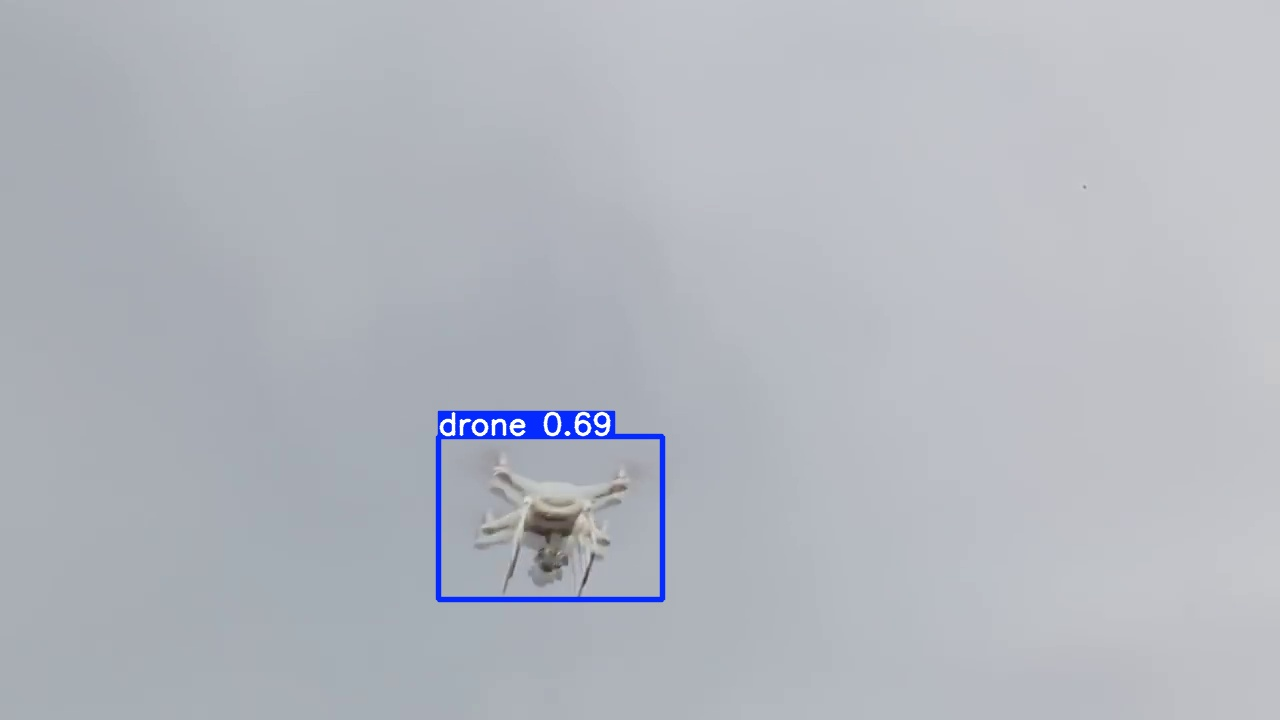

In [9]:
# ════════════════════════════════════════════════════════════
# CELL 10 - Visual test on validation images
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path
import random

best = YOLO('/content/runs/drone_final/weights/best.pt')
val_imgs = list(Path('/content/merged/valid/images').glob('*'))
sample   = random.sample(val_imgs, min(8, len(val_imgs)))
out_dir  = Path('/content/test_preds')
out_dir.mkdir(exist_ok=True)

for img_path in sample:
    best.predict(str(img_path), conf=0.35, save=True,
                 project=str(out_dir), name='run', exist_ok=True, verbose=False)
    saved = sorted((out_dir/'run').glob('*.jpg'), key=lambda p: p.stat().st_mtime)
    if saved:
        tag = 'CUSTOM-3D' if img_path.name.startswith('c_') else 'OUTDOOR'
        print(f'[{tag}] {img_path.name}')
        display(Image(str(saved[-1]), width=640))

In [10]:
# ════════════════════════════════════════════════════════════
# CELL 11 - Export to NCNN (Raspberry Pi)
# ════════════════════════════════════════════════════════════
from ultralytics import YOLO

best = YOLO('/content/runs/drone_final/weights/best.pt')
best.export(format='ncnn', imgsz=640)
print('NCNN export done.')
!ls /content/runs/drone_final/weights/

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs

PyTorch: starting from '/content/runs/drone_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (109.1 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 173ms
Prepared 1 package in 401ms
Installed 1 package in 2ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 

In [12]:
# ════════════════════════════════════════════════════════════
# CELL 12 - Zip & download to your PC
# ════════════════════════════════════════════════════════════
import shutil
from pathlib import Path
from google.colab import files

weights_dir = Path('/content/runs/drone_final/weights')
shutil.make_archive('/content/drone_models', 'zip', str(weights_dir))

sz = Path('/content/drone_models.zip').stat().st_size / 1e6
print(f'drone_models.zip  →  {sz:.1f} MB')
print('\nContents:')
!ls -lh /content/runs/drone_final/weights/

print('\nDownloading to your PC...')
files.download('/content/drone_models.zip')

drone_models.zip  →  2563.7 MB

Contents:
total 2.5G
drwxr-xr-x 3 root root 4.0K Jun 13 10:16 best_ncnn_model
-rw-r--r-- 1 root root 110M Jun 13 10:14 best.pt
-rw-r--r-- 1 root root 289M Jun 13 08:40 epoch0.pt
-rw-r--r-- 1 root root 289M Jun 13 08:52 epoch10.pt
-rw-r--r-- 1 root root 289M Jun 13 09:04 epoch20.pt
-rw-r--r-- 1 root root 289M Jun 13 09:16 epoch30.pt
-rw-r--r-- 1 root root 289M Jun 13 09:28 epoch40.pt
-rw-r--r-- 1 root root 289M Jun 13 09:40 epoch50.pt
-rw-r--r-- 1 root root 289M Jun 13 09:52 epoch60.pt
-rw-r--r-- 1 root root 289M Jun 13 10:04 epoch70.pt
-rw-r--r-- 1 root root 110M Jun 13 10:14 last.pt



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## After downloading `drone_models.zip`
Extract it → put `best.pt` in `C:\Users\BLShaw\Desktop\Drone\`

**Test on PC:**
```python
from ultralytics import YOLO
model = YOLO('best.pt')
model.predict('test.jpg', conf=0.35, show=True)
```

**Pi with NCNN:** Copy `best_ncnn_model/` folder → `MODEL_PATH = 'best_ncnn_model'`